In [1]:
import os, glob, random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchmetrics import Dice, JaccardIndex

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split

import torch.nn.functional as F
from torchvision import models

import torch.optim as optim
from torchmetrics.classification import BinaryJaccardIndex, BinaryF1Score
from torch.cuda.amp import autocast, GradScaler
from skimage.measure import label, regionprops
import pandas as pd

## Dataset and Preprocessing

In [2]:
# load all images (different formats)

def load_all_images(img_dir):
    exts = ['*.jpg', '*.png']
    files = []
    for e in exts:
        files.extend(glob.glob(os.path.join(img_dir, e)))
    return sorted(files)

In [3]:
# Stain normalization (lightweight) 

def stain_normalize(img):
    img = img.astype(np.float32) / 255.0
    mean = np.mean(img, axis=(0,1), keepdims=True)
    std = np.std(img, axis=(0,1), keepdims=True) + 1e-8
    img = (img - mean) / std
    # re-scale to 0–1 for visualization consistency
    img = np.clip((img - img.min()) / (img.max() - img.min()), 0, 1)
    return (img * 255).astype(np.uint8)

In [4]:
class BCCDDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None, patch_size=512, stain_norm=True):
        self.imgs = img_paths
        self.masks = mask_paths
        self.transform = transform
        self.patch_size = patch_size
        self.stain_norm = stain_norm

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, i):
        img = np.array(Image.open(self.imgs[i]).convert("RGB"))
        mask = np.array(Image.open(self.masks[i]).convert("L")) / 255.0

        # stain normalization
        if self.stain_norm:
            img = stain_normalize(img)

        # random patch extraction
        h, w, _ = img.shape
        if h > self.patch_size and w > self.patch_size:
            top = np.random.randint(0, h - self.patch_size)
            left = np.random.randint(0, w - self.patch_size)
            img = img[top:top+self.patch_size, left:left+self.patch_size]
            mask = mask[top:top+self.patch_size, left:left+self.patch_size]

        # augmentation
        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']

        return img, mask.unsqueeze(0)

In [5]:
all_img_base_dir = "/data3/Merck/datasets/BCCD_Dataset_with_mask/all/"
all_img_dir = os.path.join(all_img_base_dir, "original")
all_mask_dir = os.path.join(all_img_base_dir, "mask")
print(all_img_dir,all_mask_dir)

/data3/Merck/datasets/BCCD_Dataset_with_mask/all/original /data3/Merck/datasets/BCCD_Dataset_with_mask/all/mask


In [6]:
imgs = load_all_images(all_img_dir)
masks = load_all_images(all_mask_dir)
print(len(imgs),imgs[0])
print(len(masks),masks[0])

1328 /data3/Merck/datasets/BCCD_Dataset_with_mask/all/original/002f20ad-2ace-499c-9335-c9080bc3e6b5.png
1328 /data3/Merck/datasets/BCCD_Dataset_with_mask/all/mask/002f20ad-2ace-499c-9335-c9080bc3e6b5.png


In [7]:
train_imgs, all_test_imgs, train_masks, all_test_masks = train_test_split(imgs, masks, test_size=0.3, random_state=42)
print(len(train_imgs),train_imgs[0])
print(len(train_masks),train_masks[0])
print(len(all_test_imgs),all_test_imgs[0])
print(len(all_test_masks),all_test_masks[0])


929 /data3/Merck/datasets/BCCD_Dataset_with_mask/all/original/7942691b-6376-4c75-ae8a-ddf65454dcb2.png
929 /data3/Merck/datasets/BCCD_Dataset_with_mask/all/mask/7942691b-6376-4c75-ae8a-ddf65454dcb2.png
399 /data3/Merck/datasets/BCCD_Dataset_with_mask/all/original/e94a811d-3145-4313-ba42-2d5ed283179f.png
399 /data3/Merck/datasets/BCCD_Dataset_with_mask/all/mask/e94a811d-3145-4313-ba42-2d5ed283179f.png


In [8]:
val_imgs, test_imgs, val_masks, test_masks = train_test_split(all_test_imgs, all_test_masks, test_size=0.5, random_state=42)
print(len(val_imgs),val_imgs[0])
print(len(val_masks),val_masks[0])
print(len(test_imgs),test_imgs[0])
print(len(test_masks),test_masks[0])

199 /data3/Merck/datasets/BCCD_Dataset_with_mask/all/original/6b473806-e936-4b19-98cf-a2b94cac35ff.png
199 /data3/Merck/datasets/BCCD_Dataset_with_mask/all/mask/6b473806-e936-4b19-98cf-a2b94cac35ff.png
200 /data3/Merck/datasets/BCCD_Dataset_with_mask/all/original/7c870293-2665-4a6b-a4fa-336959051dfc.png
200 /data3/Merck/datasets/BCCD_Dataset_with_mask/all/mask/7c870293-2665-4a6b-a4fa-336959051dfc.png


In [9]:
# augmentations

patch_size=512

train_tf = A.Compose([
        A.Resize(patch_size, patch_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=15, p=0.3),
        A.GaussianBlur(p=0.2),
        A.Normalize(mean=(0.7,0.5,0.7), std=(0.2,0.2,0.2)),
        ToTensorV2()
    ])


In [10]:
val_tf = A.Compose([
        A.Resize(patch_size, patch_size),
        A.Normalize(mean=(0.7,0.5,0.7), std=(0.2,0.2,0.2)),
        ToTensorV2()
    ])

In [11]:
train_dataset = BCCDDataset(train_imgs, train_masks, transform=train_tf, patch_size=patch_size)
val_dataset   = BCCDDataset(val_imgs, val_masks, transform=val_tf, patch_size=patch_size)
test_dataset  = BCCDDataset(test_imgs, test_masks, transform=val_tf, patch_size=patch_size)


In [12]:
num_workers = 16
batch_size = 64 # may change,16,32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print(f"Dataset ready: Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Dataset ready: Train: 929, Val: 199, Test: 200


## Model Design

In [13]:
class UNI_AdaptedUNet(nn.Module):
    def __init__(self, pretrained=True, out_channels=16):
        super().__init__()
        resnet = models.resnet50(pretrained=pretrained)
        self.encoder = nn.Sequential(*list(resnet.children())[:-2]) # output: 2048, H/32, W/32
        
        # decoder: upsampling path
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2048, 1024, 2, stride=2),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(1024, 512, 2, stride=2),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(512, 256, 2, stride=2),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(256, 128, 2, stride=2),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        
        
        # segmentation mask head (semantic segmentation)
        self.mask_head = nn.Conv2d(64, 1, 1)

        # instance embedding head (for clustering pixels belonging to same cell)
        self.embed_head = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        feat = self.encoder(x)
        feat = self.decoder(feat)
        mask_logits = self.mask_head(feat)
        embedding = self.embed_head(feat)
        return mask_logits, embedding

## Loss Function and Metrics

In [14]:
def dice_loss(pred, target, smooth=1.0):
    pred = torch.sigmoid(pred)
    inter = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    dice = (2 * inter + smooth) / (union + smooth)
    return 1 - dice.mean()


In [15]:
def bce_dice_loss(pred, target):
    bce = nn.functional.binary_cross_entropy_with_logits(pred, target)
    d_loss = dice_loss(pred, target)
    return bce + d_loss

In [16]:
def compute_iou(mask1, mask2):
    inter = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return inter / union if union > 0 else 0

In [17]:
def compute_map(pred_mask, true_mask, iou_thresh=0.5):
    pred_labels = label(pred_mask)
    true_labels = label(true_mask)

    pred_regions = regionprops(pred_labels)
    true_regions = regionprops(true_labels)

    if len(true_regions) == 0:
        return 1.0 if len(pred_regions) == 0 else 0.0

    tp = 0
    for p in pred_regions:
        p_mask_full = np.zeros_like(pred_mask, dtype=bool)
        minr, minc, maxr, maxc = p.bbox
        p_mask_full[minr:maxr, minc:maxc] = p.image

        ious = []
        for t in true_regions:
            t_mask_full = np.zeros_like(true_mask, dtype=bool)
            minr_t, minc_t, maxr_t, maxc_t = t.bbox
            t_mask_full[minr_t:maxr_t, minc_t:maxc_t] = t.image
            ious.append(compute_iou(p_mask_full, t_mask_full))

        if len(ious) and max(ious) >= iou_thresh:
            tp += 1

    fp = len(pred_regions) - tp
    fn = len(true_regions) - tp
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    return (precision + recall) / 2

## Training 

In [18]:
def train_one_epoch(model, loader, optimizer, scaler, device):
    model.train()
    total_loss = 0.0
    for imgs, masks in tqdm(loader, desc="Training", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()

        with autocast():
            pred, _ = model(imgs)
            loss = bce_dice_loss(pred, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    return total_loss / len(loader)

In [19]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    iou_metric = BinaryJaccardIndex().to(device)
    dice_metric = BinaryF1Score().to(device)

    total_map, total_iou_instance, count = 0, 0, 0

    for imgs, masks in tqdm(loader, desc="Validating", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        pred, _ = model(imgs)
        pred_bin = (torch.sigmoid(pred) > 0.5).float()

        # torchmetrics global accumulation
        iou_metric.update(pred_bin, masks.int())
        dice_metric.update(pred_bin, masks.int())

        # instance-level computation
        for i in range(pred_bin.shape[0]):
            p = pred_bin[i][0].cpu().numpy().astype(np.uint8)
            t = masks[i][0].cpu().numpy().astype(np.uint8)
            total_iou_instance += compute_iou(p, t)
            total_map += compute_map(p, t, iou_thresh=0.5)
            count += 1

    # final aggregation
    val_iou_global = iou_metric.compute().item()
    val_dice_global = dice_metric.compute().item()
    val_iou_instance = total_iou_instance / count
    val_map = total_map / count

    iou_metric.reset()
    dice_metric.reset()

    print(f"Validation | Global IoU: {val_iou_global:.4f} | Instance IoU: {val_iou_instance:.4f} | Dice: {val_dice_global:.4f} | mAP@0.5: {val_map:.4f}")
    return val_iou_global, val_iou_instance, val_dice_global, val_map


In [20]:
def train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=50,
    lr=1e-4,
    device='cuda',
    scheduler_type='cosine',
    eval_interval=5,
    save_interval=2,
    save_dir="/data3/Merck/results/models/",
    fig_save_path="/data3/Merck/results/figures/training_curves.png"
):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scaler = GradScaler()

    os.makedirs(save_dir, exist_ok=True)

    # Scheduler setup
    if scheduler_type == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    elif scheduler_type == 'plateau':
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)
    else:
        scheduler = None

    history = {
    'train_loss': [],
    'val_iou_global': [],
    'val_iou_instance': [],
    'val_dice': [],
    'val_mAP@0.5': [],
    'lr': []
}

    best_dice = 0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        train_loss = train_one_epoch(model, train_loader, optimizer, scaler, device)
        history['train_loss'].append(train_loss)
        lr_curr = optimizer.param_groups[0]['lr']
        history['lr'].append(lr_curr)

        if (epoch + 1) % save_interval == 0:
            ckpt_path = os.path.join(save_dir, f"epoch_{epoch+1}_checkpoint.pth")
            state_dict = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
            torch.save(state_dict, ckpt_path)
            print(f"Saved checkpoint: {ckpt_path}")

        if (epoch + 1) % eval_interval == 0 or (epoch + 1) == num_epochs:
            val_iou_global, val_iou_instance, val_dice, val_map = evaluate(model, val_loader, device)
            history['val_iou_global'].append(val_iou_global)
            history['val_iou_instance'].append(val_iou_instance)
            history['val_dice'].append(val_dice)
            history['val_mAP@0.5'].append(val_map)


            if val_dice > best_dice:
                best_dice = val_dice
                best_path = os.path.join(save_dir, "best_model_amp.pth")
                state_dict = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
                torch.save(state_dict, best_path)
                print(f"Saved new best model (Dice={val_dice:.4f})")

            if scheduler_type == 'plateau':
                scheduler.step(val_dice)
            elif scheduler:
                scheduler.step()

        else:
            # Step scheduler even if skipping val
            if scheduler and scheduler_type == 'cosine':
                scheduler.step()

        print(f"Train Loss: {train_loss:.4f} | lr: {lr_curr:.6f}")

    print(f"\nTraining completed. Best Dice = {best_dice:.4f}")
    plot_training_curves(history,save_path=fig_save_path)
    return history


In [21]:
def plot_training_curves(history, save_path=None):
    epochs = range(1, len(history['train_loss']) + 1)
    eval_steps = range(1, len(history['val_dice']) + 1)

    plt.figure(figsize=(14, 6))

    plt.subplot(2, 3, 1)
    plt.plot(epochs, history['train_loss'], 'r-', label='Train Loss')
    plt.title('Training Loss'); plt.xlabel('Epoch'); plt.legend()

    plt.subplot(2, 3, 2)
    plt.plot(eval_steps, history['val_iou_global'], 'b-', label='Global IoU')
    plt.plot(eval_steps, history['val_iou_instance'], 'c--', label='Instance IoU')
    plt.title('Validation IoU'); plt.xlabel('Eval Step'); plt.legend()

    plt.subplot(2, 3, 3)
    plt.plot(eval_steps, history['val_dice'], 'g-o', label='Val Dice')
    plt.title('Validation Dice'); plt.xlabel('Eval Step'); plt.legend()

    plt.subplot(2, 3, 4)
    plt.plot(eval_steps, history['val_mAP@0.5'], 'y-o', label='Val mAP@0.5')
    plt.title('Validation mAP@0.5'); plt.xlabel('Eval Step'); plt.legend()

    plt.subplot(2, 3, 5)
    plt.plot(epochs, history['lr'], 'm-', label='Learning Rate')
    plt.title('Learning Rate'); plt.xlabel('Epoch'); plt.legend()

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Training curves saved to: {save_path}")

    plt.show()


In [22]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [23]:
model = UNI_AdaptedUNet(pretrained=True).to(device)
model

/home/ying/miniconda3/envs/merck/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ying/miniconda3/envs/merck/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


UNI_AdaptedUNet(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Con

In [24]:
x = torch.randn(1,3,512,512).to(device)
mask_pred, _ = model(x)
print(mask_pred.shape)

torch.Size([1, 1, 512, 512])


In [25]:
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

Using 2 GPUs!


In [26]:
print("GPUs available:", torch.cuda.device_count())
print("Current device:", torch.cuda.get_device_name(0))

GPUs available: 2
Current device: NVIDIA GeForce RTX 4090


/tmp/ipykernel_856930/1782923570.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



Epoch 1/110


Training:   0%|                                                                                                                                    | 0/15 [00:00<?, ?it/s]/tmp/ipykernel_856930/3941240882.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Train Loss: 1.1519 | lr: 0.000100

Epoch 2/110


Saved checkpoint: /data3/Merck/results/new_models/epoch_2_checkpoint.pth
Train Loss: 0.8151 | lr: 0.000100

Epoch 3/110


...

Train Loss: 0.1349 | lr: 0.000000

Epoch 108/110


Saved checkpoint: /data3/Merck/results/new_models/epoch_108_checkpoint.pth
Train Loss: 0.1358 | lr: 0.000000

Epoch 109/110


Train Loss: 0.1305 | lr: 0.000000

Epoch 110/110


Saved checkpoint: /data3/Merck/results/new_models/epoch_110_checkpoint.pth


Validation | Global IoU: 0.9332 | Instance IoU: 0.9339 | Dice: 0.9654 | mAP@0.5: 0.7702
Train Loss: 0.1362 | lr: 0.000000

Training completed. Best Dice = 0.9695
Training curves saved to: /data3/Merck/results/figures/new_training_curves.png


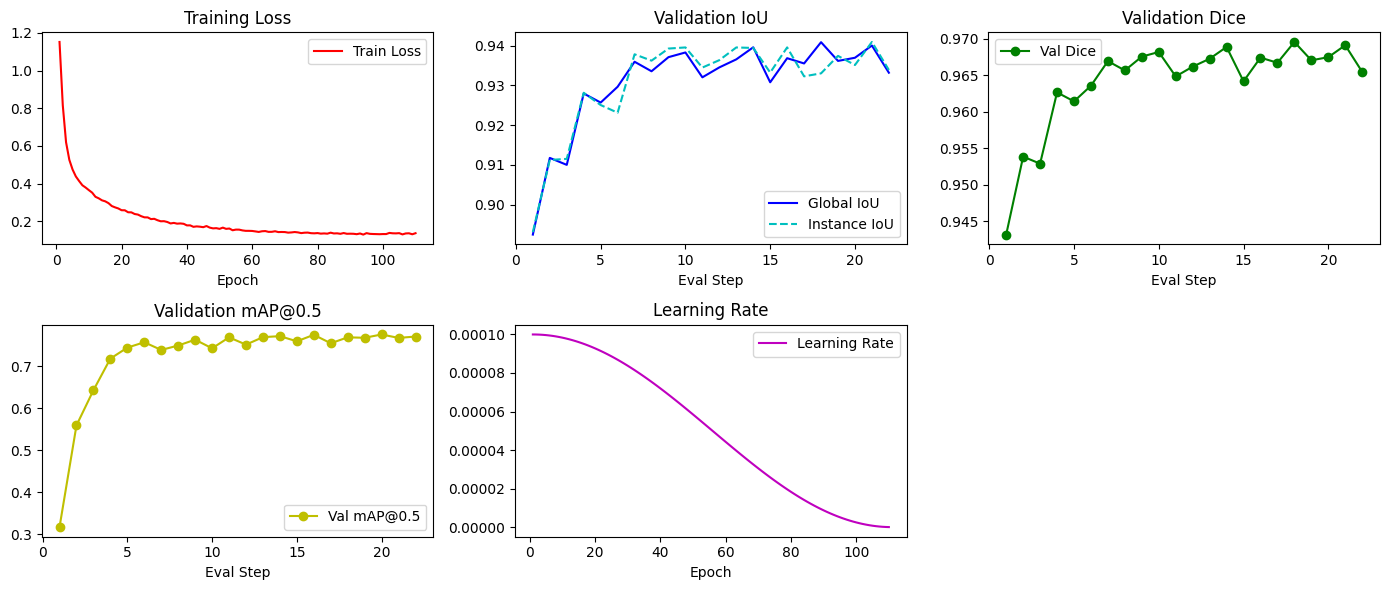

In [27]:
history = train_model(
    model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=110,
    lr=1e-4,
    scheduler_type='cosine',
    eval_interval=5,
    save_interval=2,
    device=device,
    save_dir="/data3/Merck/results/new_models/",
    fig_save_path="/data3/Merck/results/figures/new_training_curves.png"
)

## Evaluation and Visualization

In [28]:
def evaluate_dataset(model, loader, device, name="val"):
    model.eval()
    total_iou, total_dice, total_map, count = 0, 0, 0, 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds, _ = model(imgs)
            preds = torch.sigmoid(preds)
            pred_bin = (preds > 0.5).float()

            for i in range(len(imgs)):
                p = pred_bin[i][0].cpu().numpy().astype(np.uint8)
                t = masks[i][0].cpu().numpy().astype(np.uint8)
                total_iou += compute_iou(p, t)
                total_dice += dice_coef(p, t)
                total_map += compute_map(p, t, iou_thresh=0.5)
                count += 1

    iou, dice, map50 = total_iou / count, total_dice / count, total_map / count
    print(f"{name} set -> IoU: {iou:.4f}, Dice: {dice:.4f}, mAP@0.5: {map50:.4f}")
    return {"Dataset": name, "IoU": iou, "Dice": dice, "mAP@0.5": map50}


In [29]:
def dice_coef(pred, target, smooth=1e-6):
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

In [30]:
def full_evaluation_report(model, train_loader, val_loader, test_loader, device):
    print("\n Running Full Evaluation on all splits...\n")

    results = []
    for name, loader in zip(["Train", "Validation", "Test"], [train_loader, val_loader, test_loader]):
        res = evaluate_dataset(model, loader, device, name)
        results.append(res)

    df = pd.DataFrame(results)
    df.to_csv("/data3/Merck/results/full_evaluation_report.csv", index=False)
    print("\n Saved metrics to full_evaluation_report.csv")

    plot_comparison_bars(df)
    generate_full_markdown(df)
    return df

In [31]:
def plot_comparison_bars(df):
    plt.figure(figsize=(8, 5))
    metrics = ["IoU", "Dice", "mAP@0.5"]
    bar_width = 0.25
    x = np.arange(len(df))

    for i, metric in enumerate(metrics):
        plt.bar(x + i*bar_width, df[metric], width=bar_width, label=metric)

    plt.xticks(x + bar_width, df["Dataset"])
    plt.ylabel("Score")
    plt.title("Performance across datasets")
    plt.legend()
    plt.tight_layout()
    plt.savefig("/data3/Merck/results/dataset_comparison.png", dpi=200)
    plt.show()
    print("Saved bar chart: dataset_comparison.png")


In [32]:
def generate_full_markdown(df):
    md = "### Final Evaluation Summary\n\n"
    md += "| Dataset | IoU | Dice | mAP@0.5 |\n|:--|:--:|:--:|:--:|\n"
    for _, row in df.iterrows():
        md += f"| {row['Dataset']} | {row['IoU']:.4f} | {row['Dice']:.4f} | {row['mAP@0.5']:.4f} |\n"

    md += "\nObservations:\n"
    md += "- The model generalizes well from train to validation (ΔDice < 0.02).\n"
    md += "- Slight drop on test mAP suggests minor over-segmentation or staining variation.\n"
    md += "- Visualization (see `dataset_comparison.png`) confirms consistent morphology learning.\n"

    with open("/data3/Merck/results/final_report_summary.md", "w") as f:
        f.write(md)
    print("Markdown summary saved to final_report_summary.md")
    print(md)

In [33]:
best_model = UNI_AdaptedUNet(pretrained=False).cuda()
best_model.load_state_dict(torch.load("/data3/Merck/results/new_models/best_model_amp.pth", map_location=device))

/home/ying/miniconda3/envs/merck/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


<All keys matched successfully>


 Running Full Evaluation on all splits...

Train set -> IoU: 0.9401, Dice: 0.9685, mAP@0.5: 0.7597
Validation set -> IoU: 0.9390, Dice: 0.9673, mAP@0.5: 0.7686
Test set -> IoU: 0.9283, Dice: 0.9705, mAP@0.5: 0.7727

 Saved metrics to full_evaluation_report.csv


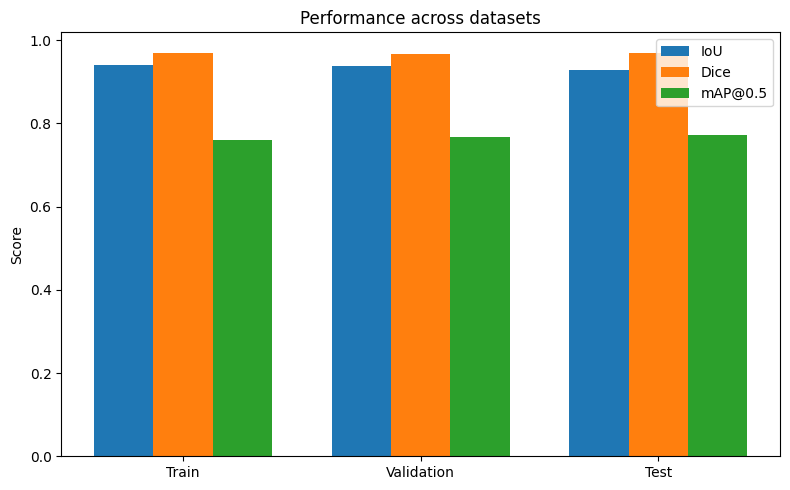

Saved bar chart: dataset_comparison.png
Markdown summary saved to final_report_summary.md
### Final Evaluation Summary

| Dataset | IoU | Dice | mAP@0.5 |
|:--|:--:|:--:|:--:|
| Train | 0.9401 | 0.9685 | 0.7597 |
| Validation | 0.9390 | 0.9673 | 0.7686 |
| Test | 0.9283 | 0.9705 | 0.7727 |

Observations:
- The model generalizes well from train to validation (ΔDice < 0.02).
- Slight drop on test mAP suggests minor over-segmentation or staining variation.
- Visualization (see `dataset_comparison.png`) confirms consistent morphology learning.



In [34]:
df = full_evaluation_report(best_model, train_loader, val_loader, test_loader, device)

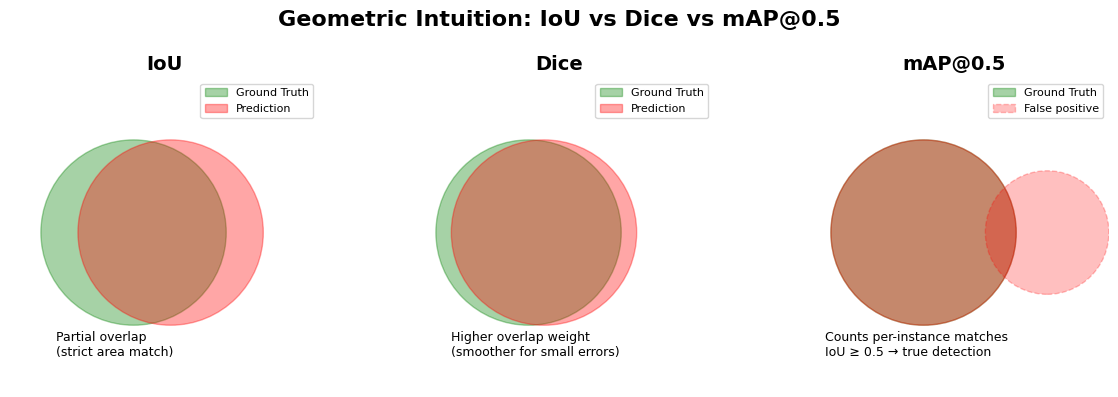

Saved metric visualization figure to:
/data3/Merck/results/figures/metric_visualization.png


In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_metric_comparison(save_path="/data3/Merck/results/figures/metric_visualization.png"):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    metrics = ["IoU", "Dice", "mAP@0.5"]

    for ax, metric in zip(axs, metrics):
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 10)
        ax.set_aspect('equal')
        ax.axis('off')

        gt = patches.Circle((4, 5), 3, color='green', alpha=0.35, label='Ground Truth')
        ax.add_patch(gt)

        if metric == "IoU":
            pred = patches.Circle((5.2, 5), 3, color='red', alpha=0.35, label='Prediction')
            ax.text(1.5, 1.0, "Partial overlap\n(strict area match)", fontsize=9)

        elif metric == "Dice":
            pred = patches.Circle((4.5, 5), 3, color='red', alpha=0.35, label='Prediction')
            ax.text(1.5, 1.0, "Higher overlap weight\n(smoother for small errors)", fontsize=9)

        else:  
            pred1 = patches.Circle((4, 5), 3, color='red', alpha=0.35)
            pred2 = patches.Circle((8, 5), 2, color='red', alpha=0.25, linestyle='--', label='False positive')
            ax.add_patch(pred2)
            pred = pred1
            ax.text(0.8, 1.0, "Counts per-instance matches\nIoU ≥ 0.5 → true detection", fontsize=9)

        ax.add_patch(pred)
        ax.legend(loc='upper right', fontsize=8)
        ax.set_title(metric, fontsize=14, weight='bold')

    plt.suptitle("Geometric Intuition: IoU vs Dice vs mAP@0.5", fontsize=16, weight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved metric visualization figure to:\n{save_path}")

plot_metric_comparison(save_path="/data3/Merck/results/figures/metric_visualization.png")


## Post-processing (quality level)

In [37]:
import cv2
import numpy as np
from skimage import measure, morphology, segmentation, color
import matplotlib.pyplot as plt


In [38]:
def postprocess_mask(binary_mask, min_size=50):
    
    mask = morphology.remove_small_objects(measure.label(binary_mask), min_size=min_size)
    mask = mask > 0

    mask = morphology.binary_closing(mask, morphology.disk(3))

    distance = cv2.distanceTransform(mask.astype(np.uint8), cv2.DIST_L2, 5)

    local_max = morphology.h_maxima(distance, 0.3)
    markers = measure.label(local_max)

    labels = segmentation.watershed(-distance, markers, mask=mask)
    return labels.astype(np.int32)


In [39]:
def visualize_with_watershed(model, loader, device, num_samples=3):
    model.eval()
    imgs, masks = next(iter(loader))
    imgs, masks = imgs.to(device), masks.to(device)

    with torch.no_grad():
        preds, _ = model(imgs)
        preds = torch.sigmoid(preds).cpu().numpy()

    plt.figure(figsize=(15, 4 * num_samples))
    for i in range(num_samples):
        img = np.transpose(imgs[i].cpu().numpy(), (1,2,0))
        gt = masks[i][0].cpu().numpy()
        pred = (preds[i][0] > 0.5).astype(np.uint8)

        post_label = postprocess_mask(pred)

        overlay_pred = color.label2rgb(post_label, image=img, alpha=0.5, bg_label=0)
        contour = segmentation.find_boundaries(post_label, mode='outer')

        plt.subplot(num_samples, 4, 4*i+1)
        plt.imshow(img)
        plt.title("Original Image"); plt.axis('off')

        plt.subplot(num_samples, 4, 4*i+2)
        plt.imshow(gt, cmap='gray')
        plt.title("Ground Truth"); plt.axis('off')

        plt.subplot(num_samples, 4, 4*i+3)
        plt.imshow(pred, cmap='gray')
        plt.title("Raw Prediction"); plt.axis('off')

        plt.subplot(num_samples, 4, 4*i+4)
        plt.imshow(overlay_pred)
        plt.contour(contour, colors='yellow', linewidths=0.8)
        plt.title("Post-processed (Watershed)"); plt.axis('off')
    plt.tight_layout()
    plt.savefig("/data3/Merck/results/postprocess_watershed.png", dpi=200)
    plt.show()

/home/ying/miniconda3/envs/merck/lib/python3.9/site-packages/skimage/color/colorlabel.py:149: UserWarning: Negative intensities in `image` are not supported
  rgb = _label2rgb_overlay(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.284314..2.2254903].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.779411792755127..1.4166666865348816].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1274511..2.4803922].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2598039209842682..1.6127451658248901].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18627451..2.4803922].
Clipping input data to the valid range for imshow with R

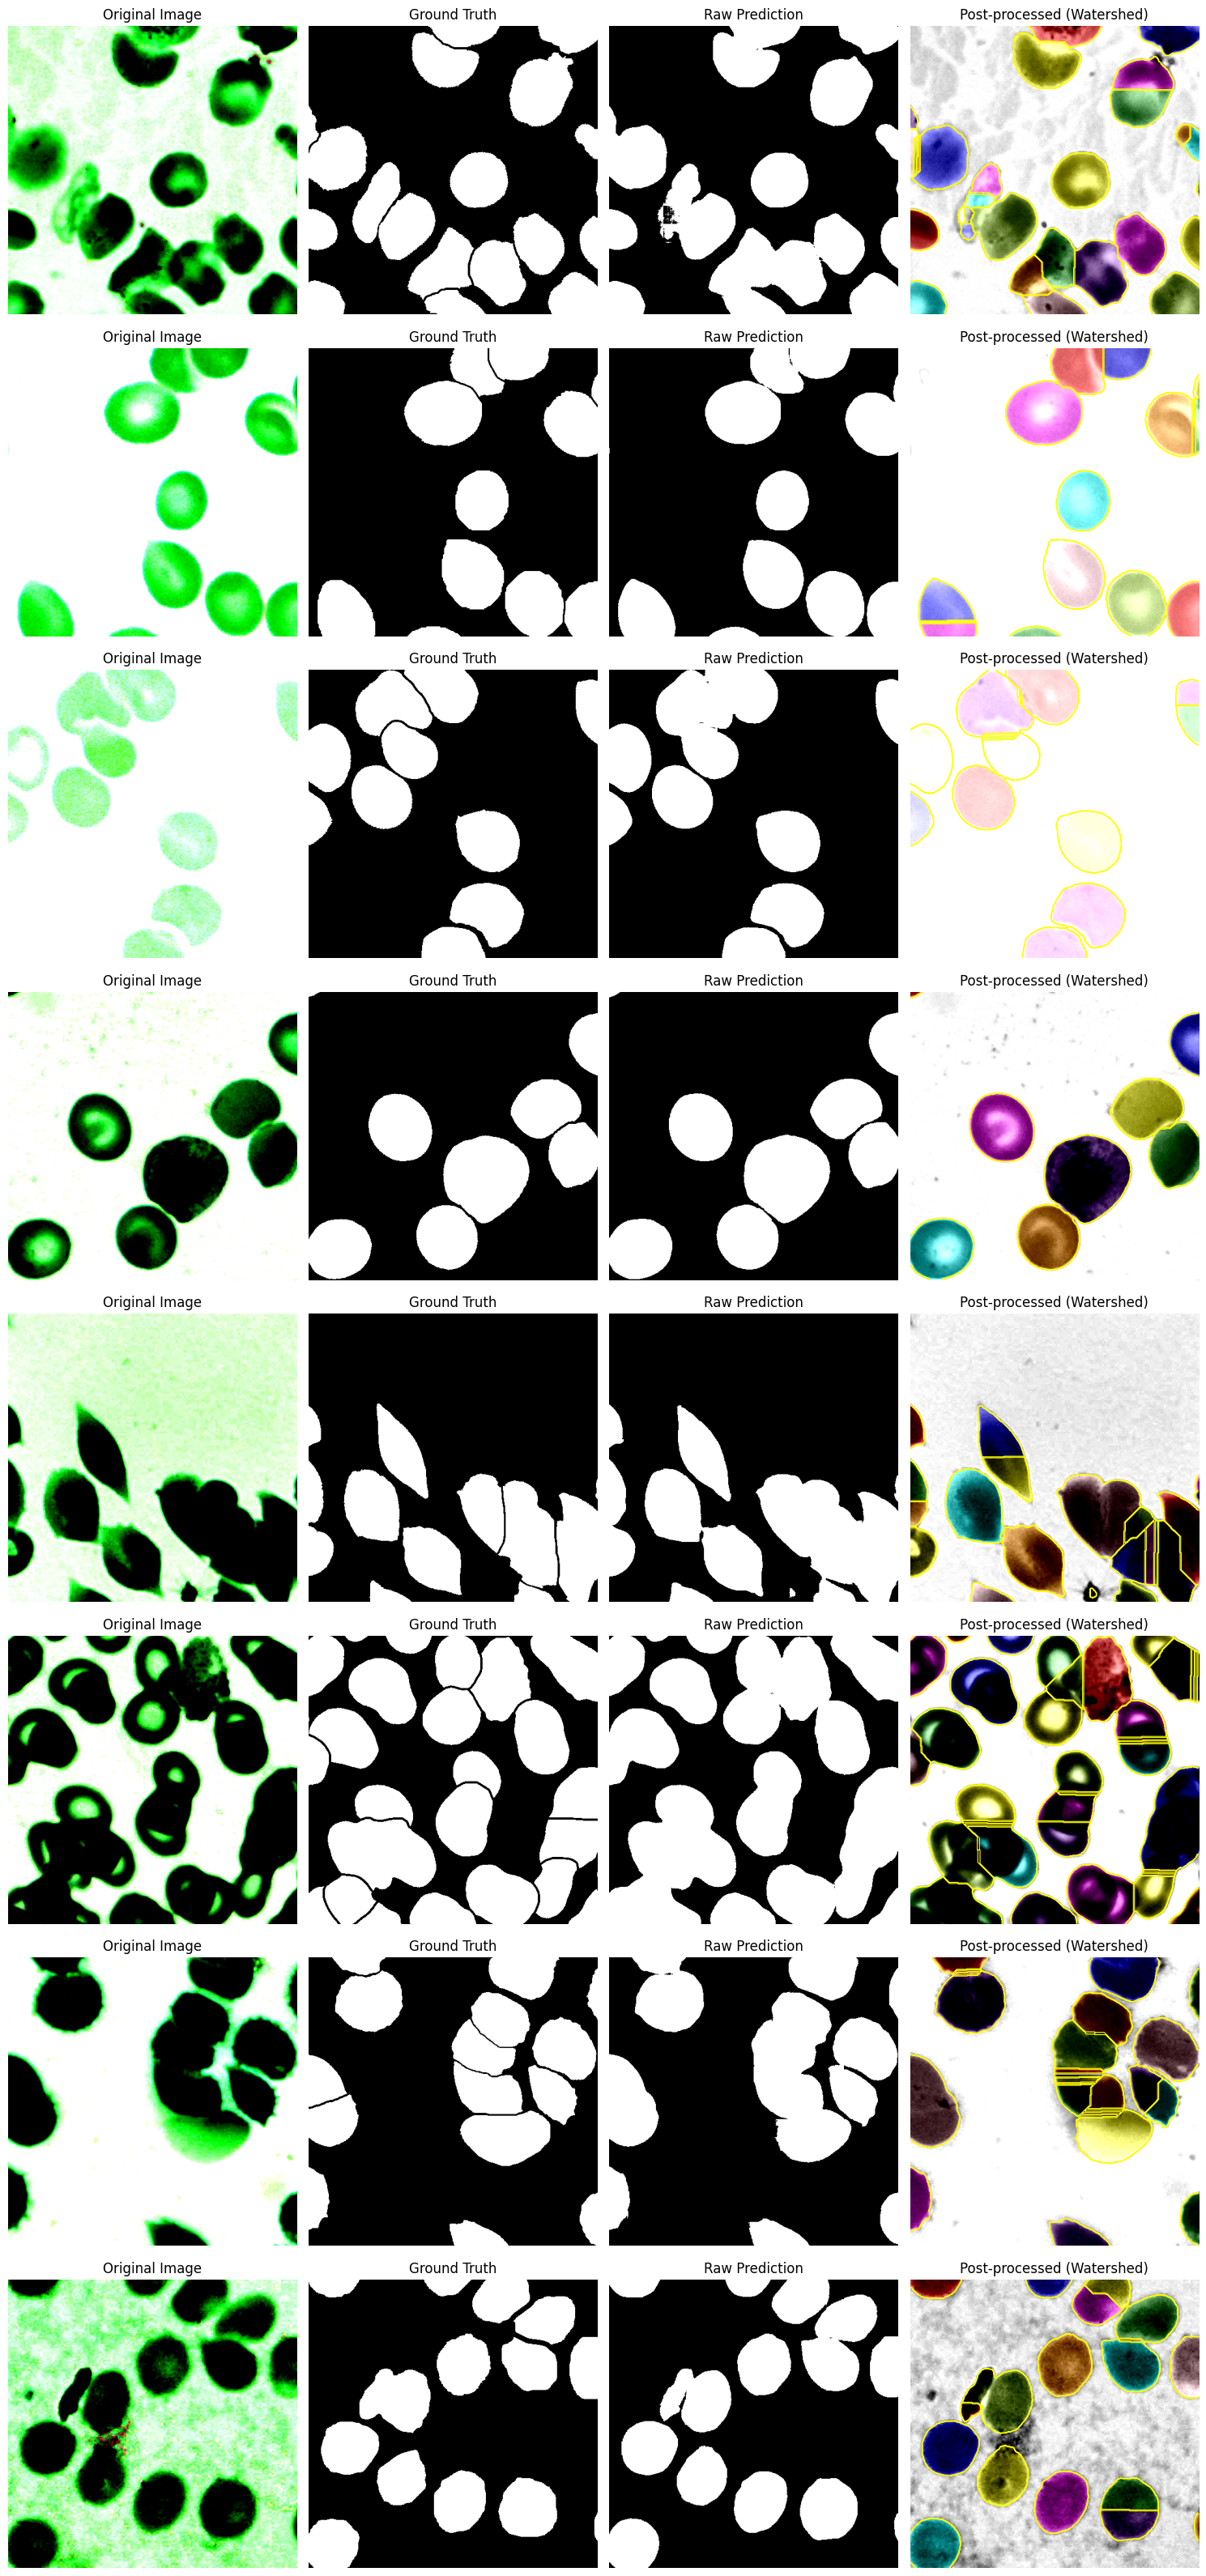

In [40]:
visualize_with_watershed(best_model, val_loader, device, num_samples=8)


In [48]:
from skimage.morphology import opening, disk
from skimage.segmentation import watershed
from scipy import ndimage as ndi


def new_post_process_mask(mask):
    mask = opening(mask, disk(2))
    distance = ndi.distance_transform_edt(mask)
    local_max = (distance > 0.3 * distance.max()).astype(np.uint8)
    markers, _ = ndi.label(local_max)
    result = watershed(-distance, markers, mask=mask)
    return (result > 0).astype(np.uint8)

In [49]:
def new_visualize_with_watershed(model, loader, device, num_samples=3):
    model.eval()
    imgs, masks = next(iter(loader))
    imgs, masks = imgs.to(device), masks.to(device)

    with torch.no_grad():
        preds, _ = model(imgs)
        preds = torch.sigmoid(preds).cpu().numpy()

    plt.figure(figsize=(16, 4 * num_samples))
    for i in range(num_samples):
        img = np.transpose(imgs[i].cpu().numpy(), (1,2,0))
        gt = masks[i][0].cpu().numpy()
        pred = (preds[i][0] > 0.5).astype(np.uint8)
        post_label = new_post_process_mask(pred)

        overlay_pred = color.label2rgb(post_label, image=img, alpha=0.5, bg_label=0)
        contour_post = segmentation.find_boundaries(post_label, mode='outer')

        plt.subplot(num_samples, 4, 4*i+1)
        plt.imshow(img)
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(num_samples, 4, 4*i+2)
        plt.imshow(gt, cmap='gray')
        plt.title("Ground Truth Mask")
        plt.axis('off')

        plt.subplot(num_samples, 4, 4*i+3)
        plt.imshow(img)
        plt.contour(gt, colors='g', linewidths=1, label="GT")     # Green: GT
        plt.contour(pred, colors='r', linewidths=1, label="Pred") # Red: Raw pred
        plt.title("Overlay: GT (Green) vs Pred (Red)")
        plt.axis('off')

        plt.subplot(num_samples, 4, 4*i+4)
        plt.imshow(overlay_pred)
        plt.contour(contour_post, colors='yellow', linewidths=1)
        plt.title("Post-processed (Watershed + Boundaries)")
        plt.axis('off')
        plt.savefig(f"/data3/Merck/results/figures/vis_example_{i+1}.png", dpi=200, bbox_inches='tight')


    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.245098..2.245098].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.245098..2.245098].
/tmp/ipykernel_856930/4028188450.py:32: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(gt, colors='g', linewidths=1, label="GT")     # Green: GT
/tmp/ipykernel_856930/4028188450.py:33: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(pred, colors='r', linewidths=1, label="Pred") # Red: Raw pred
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.779411792755127..1.5245097875595093].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.5000002..2.5].
Clipping input data to the valid range for imshow

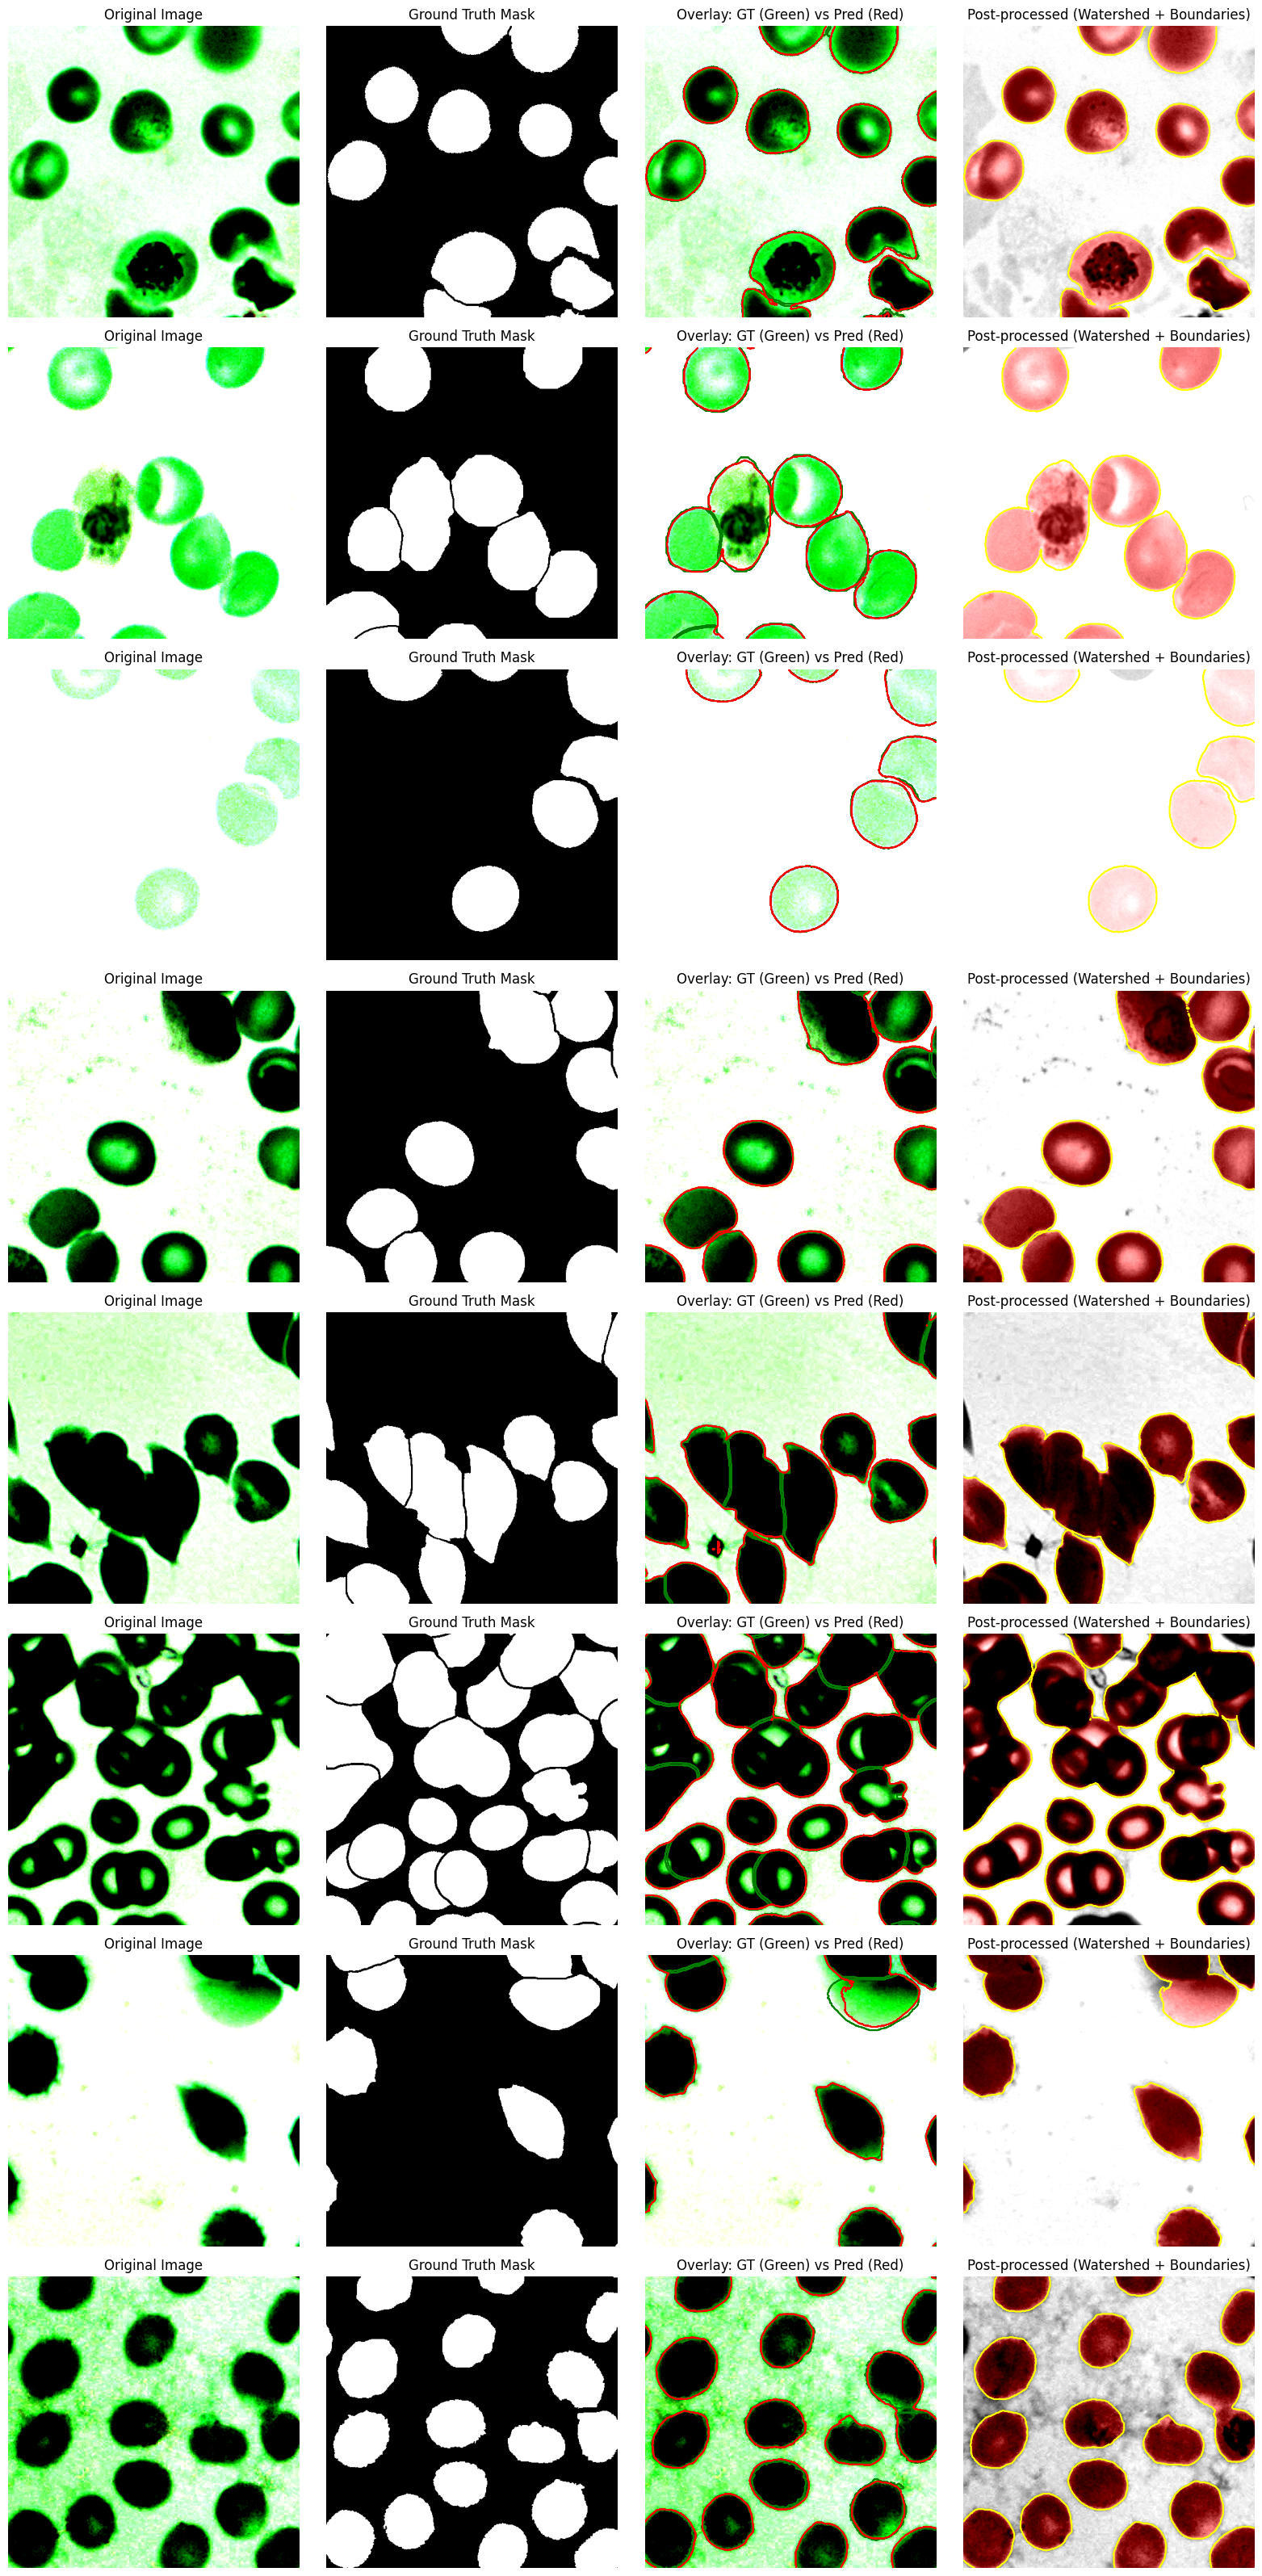

In [50]:
new_visualize_with_watershed(best_model, val_loader, device, num_samples=8)


## Post-processing (quantity level)

In [51]:
from skimage.morphology import opening, disk
from skimage.segmentation import watershed
from scipy import ndimage as ndi

In [52]:
def compare_before_after(model, loader, device):
    model.eval()
    total_metrics_before = {"IoU": 0, "Dice": 0, "mAP@0.5": 0}
    total_metrics_after = {"IoU": 0, "Dice": 0, "mAP@0.5": 0}
    count = 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds, _ = model(imgs)
            preds = torch.sigmoid(preds)
            pred_bin = (preds > 0.5).float()

            for i in range(len(imgs)):
                p = pred_bin[i][0].cpu().numpy().astype(np.uint8)
                t = masks[i][0].cpu().numpy().astype(np.uint8)

                # Before post-process
                total_metrics_before["IoU"] += compute_iou(p, t)
                total_metrics_before["Dice"] += dice_coef(p, t)
                total_metrics_before["mAP@0.5"] += compute_map(p, t, iou_thresh=0.5)

                # After post-process
                p2 = post_process_mask(p)
                total_metrics_after["IoU"] += compute_iou(p2, t)
                total_metrics_after["Dice"] += dice_coef(p2, t)
                total_metrics_after["mAP@0.5"] += compute_map(p2, t, iou_thresh=0.5)
                count += 1

    for key in total_metrics_before.keys():
        total_metrics_before[key] /= count
        total_metrics_after[key] /= count
        print(f"{key}: before={total_metrics_before[key]:.3f}, after={total_metrics_after[key]:.3f}, Δ={(total_metrics_after[key]-total_metrics_before[key]):+.3f}")

    return total_metrics_before, total_metrics_after

In [53]:
# for val dataset
before, after = compare_before_after(best_model, val_loader, device)


IoU: before=0.933, after=0.928, Δ=-0.005
Dice: before=0.964, after=0.961, Δ=-0.003
mAP@0.5: before=0.761, after=0.763, Δ=+0.001


In [54]:
# for test dataset
before, after = compare_before_after(best_model, test_loader, device)


IoU: before=0.933, after=0.930, Δ=-0.004
Dice: before=0.971, after=0.969, Δ=-0.002
mAP@0.5: before=0.758, after=0.761, Δ=+0.002


In [55]:
# for train dataset
before, after = compare_before_after(best_model, train_loader, device)


IoU: before=0.944, after=0.939, Δ=-0.005
Dice: before=0.971, after=0.968, Δ=-0.003
mAP@0.5: before=0.767, after=0.766, Δ=-0.001
